# hydro2dRP Example Notebook - Single Streamgage

## Imports, Setup and Data

In [1]:
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import colorcet as cc
from statsmodels.distributions.copula.api import GumbelCopula

import gumbel_copula_2dRP as rp
import RP_plotting as rp_plot

In [2]:
# set up plot preferences
plt.rcParams['font.sans-serif'] = 'Helvetica'
plt.rcParams['font.size'] = 8
cmap = cc.cm['kbc_r']

# set up grid of u and v values for dependence space
n = 5000
u_vals = np.linspace(0.8, 0.999, n)
v_vals = np.linspace(0.8, 0.999, n)

# return periods
T = [5, 10, 20, 50, 100]

In [3]:
# import sample data
data = pd.read_csv(
    'sample_data_nwm.csv',
    index_col = 'site',
    parse_dates=['start', 'end']
)

## Fit the Marginals and Copula Function

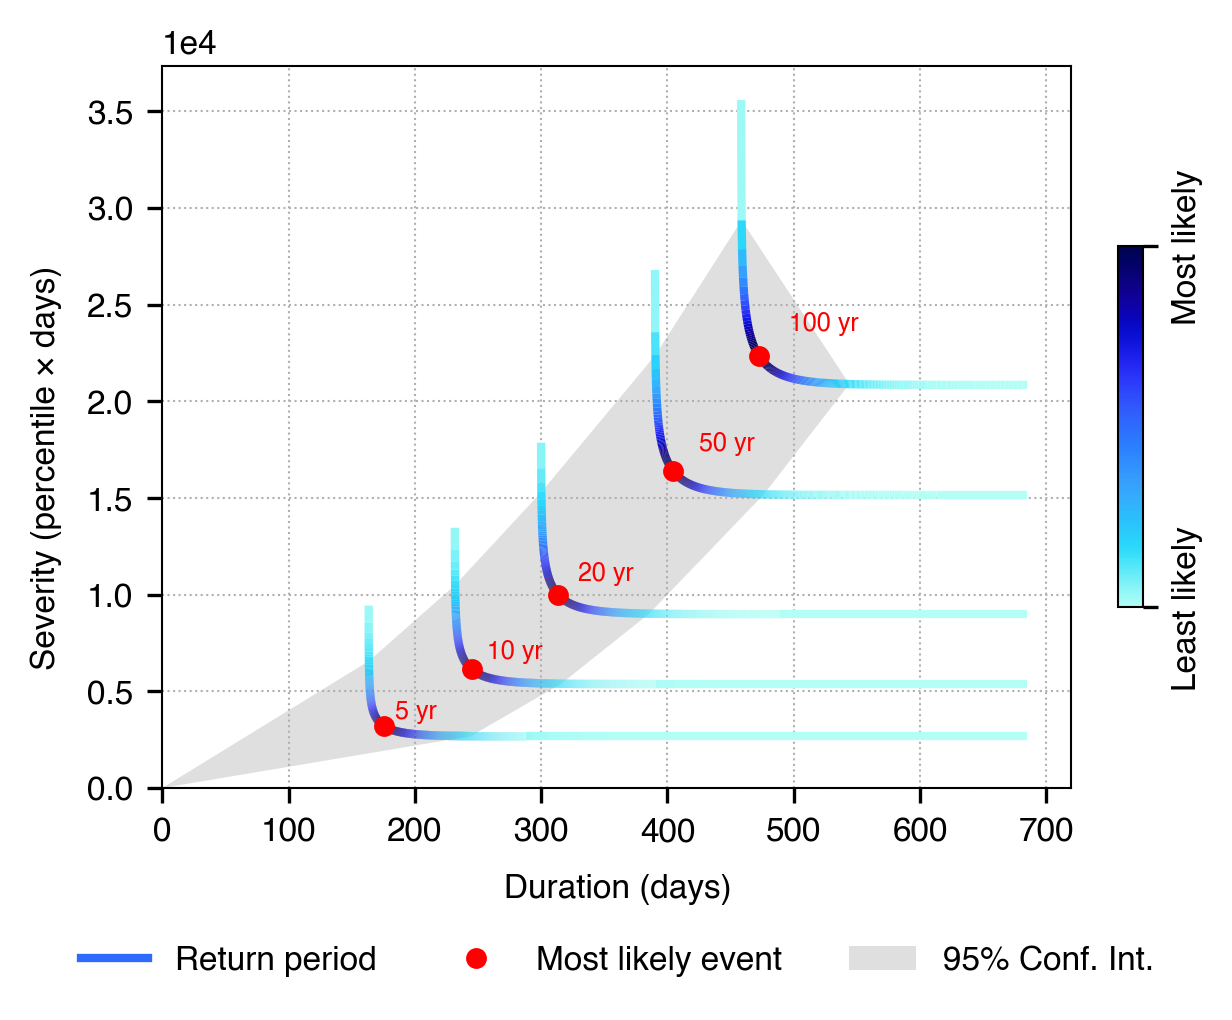

In [4]:
out_duration = []   # the most likely duration values
out_severity = []   # the most likely severity values
out_upper_d = []    # CI bounds
out_lower_d = []
out_upper_s = []
out_lower_s = []


fig, ax = plt.subplots(
    figsize=(4, 3),
    dpi=300,
    layout='constrained'
)

D = data['duration'].values
S = data['severity'].values

# Fit EVs
duration_rv, duration_params, duration_aic = rp.best_fit_rv(D, ['gamma', 'weibull_min', 'expon'], print_out=False)
severity_rv, severity_params, severity_aic = rp.best_fit_rv(S, ['gamma', 'weibull_min', 'expon'], print_out=False)

duration_rv = duration_rv(*duration_params)
severity_rv = severity_rv(*severity_params)

# fit theta
copula = GumbelCopula()
theta = copula.fit_corr_param(
    np.vstack((D, S)).transpose()
    )


all_duration = []
all_severity = []
all_likelihood = []
max_duration = []       # duration value with max likelihood
max_severity = []       # severity value with max likelihood
CI_upper_x = [0]
CI_upper_y = [0]
CI_lower_x = [0]
CI_lower_y =[0]

for t in T:

    # compute the iso-line
    V = rp.gumbel_kendall_isoline(u_vals, 1 - 1/t, theta)
    
    # transform to duration and severity values
    duration_val = duration_rv.ppf(u_vals)
    severity_val = severity_rv.ppf(V)
    all_duration.append(duration_val)
    all_severity.append(severity_val)

    # compute the likelihood along iso-RP
    likelihood = rp.joint_density(u_vals, V, theta, duration_rv, severity_rv)
    # Normalize likelihood to [0, 1], ignoring NaN values
    min_val = np.nanmin(likelihood)
    max_val = np.nanmax(likelihood)
    if max_val != min_val:
        likelihood_normalized = (likelihood - min_val) / (max_val - min_val)
    else:
        likelihood_normalized = np.zeros_like(likelihood)
    
    all_likelihood.append(likelihood_normalized)
    
    # get the duration and severity values at the max likelihood of the iso-line
    ind_max = np.nanargmax(likelihood_normalized)
    max_duration.append(duration_val[ind_max])
    max_severity.append(severity_val[ind_max])
    
    # compute the 95% confidence interval around the max likelihood
    logL = np.log(likelihood)
    logL_max = np.nanmax(logL)
    threshold = logL_max - 0.5 * sp.stats.chi2.ppf(0.95, df=1)
    mask = logL >= threshold
    dur_ci = duration_val[mask]
    sev_ci = severity_val[mask]
    
    CI_upper_x.append(np.min(dur_ci))
    CI_upper_y.append(np.max(sev_ci))
    CI_lower_x.append(np.max(dur_ci))
    CI_lower_y.append(np.min(sev_ci))

# to shade the CI area, need to interpolate to a shared x grid
x1 = np.array(CI_upper_x)
y1 = np.array(CI_upper_y)

x2 = np.array(CI_lower_x)
y2 = np.array(CI_lower_y)

# polygon for p_fill
x_poly = np.concatenate([
    x1,
    [x2[-1]],   # straight line to end of line 2
    x2[::-1],
    [x1[0]]     # straight line back to start of line 1
])

y_poly = np.concatenate([
    y1,
    [y2[-1]],
    y2[::-1],
    [y1[0]]
])

# plot the iso-lines colored by likelihood
for t in range(len(T)):
    lc = rp_plot.colored_line(
        all_duration[t],
        all_severity[t],
        all_likelihood[t],
        cmap=cmap,
        norm=plt.Normalize(0, 1),
        linewidth=2)
    
    ax.add_collection(lc)


# plot the max likelihood events
ax.plot(
    max_duration,
    max_severity,
    linestyle='',
    marker='o',
    color='r',
    ms=4,
    label='Most likely event'
)

# label each max likelihood event with corresponding return period
for i, t in enumerate(T):
    ax.text(max_duration[i] * 1.05, max_severity[i] * 1.05, f'{t} yr', fontsize=6, ha='left', va='bottom', color='r')

# fill the CI region
ax.fill(
    x_poly,
    y_poly,
    color='silver', #cmap(0.95),
    linewidth=0,
    alpha=0.5,
    label='95% Conf. Int.'
    )


# proxy object for iso-line legend item
proxy = mlines.Line2D(
    [], [],
    color=cmap(0.5),
    linewidth=2
)

out_duration.append(max_duration)
out_severity.append(max_severity)
out_upper_d.append(CI_upper_x[1:])
out_lower_d.append(CI_lower_x[1:])
out_upper_s.append(CI_upper_y[1:])
out_lower_s.append(CI_lower_y[1:])

cbar = fig.colorbar(lc, ax=ax, ticks=[0,1], shrink=0.5, aspect=15)
ax.set_ylim(0)
ax.set_xlim(0)
ax.spines[:].set_linewidth(0.5)
ax.grid('major', linewidth=0.5, linestyle=':')
ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
fig.supxlabel('Duration (days)', fontsize=8)
fig.supylabel('Severity (percentile \u00D7 days)', fontsize=8)

cbar.ax.spines['outline'].set(visible=True, lw=0.5, edgecolor='black')
cbar.ax.set_yticklabels(['Least likely', 'Most likely'], va='center', rotation=90)

handles, labels = ax.get_legend_handles_labels()
handles.insert(0, proxy)
labels.insert(0, 'Return period')
# ax.legend(handles, labels)
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.1), ncols=3, frameon=False, fontsize=8)